In [ ]:
!pip install timm seaborn scikit-learn -q
print("✅ Libraries installed!")

✅ Libraries installed!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [ ]:
import zipfile, os

zip_path     = "/content/drive/MyDrive/archive (3).zip"
extract_path = "/content/dataset"

if not os.path.exists(extract_path):
    print("Extracting dataset... please wait...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    print("✅ Extraction complete!")
else:
    print("✅ Dataset already extracted!")

# Confirm structure
CLASS_TASK = "/content/dataset/brisc2025/classification_task"
print(f"\nTrain classes : {os.listdir(os.path.join(CLASS_TASK, 'train'))}")
print(f"Test  classes : {os.listdir(os.path.join(CLASS_TASK, 'test'))}")

Extracting dataset... please wait...
✅ Extraction complete!

Train classes : ['no_tumor', 'pituitary', 'glioma', 'meningioma']
Test  classes : ['no_tumor', 'pituitary', 'glioma', 'meningioma']


In [ ]:
# =============================================================================
# CLEANUP — Run this first, then re-run Cell 4 and Cell 5
# =============================================================================
import shutil

# Remove old broken pool
if os.path.exists('/content/data_pool'):
    shutil.rmtree('/content/data_pool')
    print("✅ Old pool deleted!")

# Verify it's gone
print(f"Pool exists: {os.path.exists('/content/data_pool')}")

✅ Old pool deleted!
Pool exists: False


In [ ]:
import shutil, hashlib
import numpy as np

POOL_DIR    = "/content/data_pool"
CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

print("Merging train + test → single pool with deduplication...")

seen_hashes = set()
counts      = {c: 0 for c in CLASS_NAMES}
duplicates  = 0

for split in ['train', 'test']:
    split_path = os.path.join(CLASS_TASK, split)
    for cls in CLASS_NAMES:
        src_dir = os.path.join(split_path, cls)
        dst_dir = os.path.join(POOL_DIR, cls)
        os.makedirs(dst_dir, exist_ok=True)

        if not os.path.exists(src_dir):
            print(f"  ⚠️  Missing: {src_dir}")
            continue

        for fname in os.listdir(src_dir):
            fpath = os.path.join(src_dir, fname)
            if not os.path.isfile(fpath):
                continue
            # MD5 deduplication
            with open(fpath, 'rb') as f:
                h = hashlib.md5(f.read()).hexdigest()
            if h in seen_hashes:
                duplicates += 1
                continue
            seen_hashes.add(h)
            # Unique filename
            ext      = os.path.splitext(fname)[1]
            dst_name = f"{cls}_{h[:10]}{ext}"
            shutil.copy2(fpath, os.path.join(dst_dir, dst_name))
            counts[cls] += 1

print(f"\n{'Class':<15} {'Images':>8}")
print("-" * 25)
total = 0
for c in CLASS_NAMES:
    print(f"{c:<15} {counts[c]:>8}")
    total += counts[c]
print(f"{'TOTAL':<15} {total:>8}")
print(f"\n✅ Duplicates removed : {duplicates}")
print(f"✅ Clean pool total   : {total}")

Merging train + test → single pool with deduplication...

Class             Images
-------------------------
glioma              1400
meningioma          1613
no_tumor            1197
pituitary           1740
TOTAL               5950

✅ Duplicates removed : 50
✅ Clean pool total   : 5950


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import timm
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time, warnings
warnings.filterwarnings('ignore')

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE    = 224
BATCH_SIZE  = 16
NUM_CLASSES = 4
NUM_WORKERS = 2
EPOCHS      = 30
N_FOLDS     = 5
SEED        = 42
DRIVE_DIR   = '/content/drive/MyDrive/brisc2025_results'
os.makedirs(DRIVE_DIR, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"✅ Device  : {DEVICE}")
if torch.cuda.is_available():
    print(f"✅ GPU     : {torch.cuda.get_device_name()}")
    print(f"✅ Memory  : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")
print(f"✅ Folds   : {N_FOLDS}  |  Epochs/fold : {EPOCHS}")

✅ Device  : cuda
✅ GPU     : Tesla T4
✅ Memory  : 14.6 GB
✅ Folds   : 5  |  Epochs/fold : 30


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1))
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load pool — no transform here, applied per fold
full_dataset = ImageFolder(POOL_DIR)
all_targets  = np.array(full_dataset.targets)
class_names  = full_dataset.classes  # auto-sorted

print(f"\n✅ Pool loaded!")
print(f"   Classes      : {class_names}")
print(f"   Total images : {len(full_dataset)}")
print(f"   Distribution : {dict(zip(class_names, np.bincount(all_targets)))}")



✅ Pool loaded!
   Classes      : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
   Total images : 5950
   Distribution : {'glioma': np.int64(1400), 'meningioma': np.int64(1613), 'no_tumor': np.int64(1197), 'pituitary': np.int64(1740)}


In [ ]:
class CBS(nn.Module):
    def __init__(self, in_c, out_c, k=1, s=1):
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, k, s, k//2, bias=False)
        self.bn   = nn.BatchNorm2d(out_c, momentum=0.03, eps=1e-3)
        self.act  = nn.SiLU(inplace=True)
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class ELAN(nn.Module):
    def __init__(self, in_c, mid_c, out_c):
        super().__init__()
        self.cv1 = CBS(in_c,    mid_c, 1)
        self.cv2 = CBS(in_c,    mid_c, 1)
        self.cv3 = CBS(mid_c,   mid_c, 3)
        self.cv4 = CBS(mid_c,   mid_c, 3)
        self.cv5 = CBS(mid_c,   mid_c, 3)
        self.cv6 = CBS(mid_c,   mid_c, 3)
        self.cv7 = CBS(4*mid_c, out_c, 1)
    def forward(self, x):
        y1 = self.cv1(x)
        y2 = self.cv2(x)
        y3 = self.cv4(self.cv3(y2))
        y4 = self.cv6(self.cv5(y3))
        return self.cv7(torch.cat([y1, y2, y3, y4], dim=1))

class SPPF(nn.Module):
    def __init__(self, in_c, out_c, k=5):
        super().__init__()
        mid       = in_c // 2
        self.cv1  = CBS(in_c,    mid,   1)
        self.cv2  = CBS(mid * 4, out_c, 1)
        self.pool = nn.MaxPool2d(k, 1, k//2)
    def forward(self, x):
        x  = self.cv1(x)
        y1 = self.pool(x)
        y2 = self.pool(y1)
        y3 = self.pool(y2)
        return self.cv2(torch.cat([x, y1, y2, y3], 1))

class YOLOv7Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem   = nn.Sequential(
            CBS(3, 32, 3, 1), CBS(32, 64, 3, 2), CBS(64, 64, 3, 1))
        self.stage1 = nn.Sequential(CBS(64,  128, 3, 2), ELAN(128,  64, 128))
        self.stage2 = nn.Sequential(CBS(128, 256, 3, 2), ELAN(256, 128, 256))
        self.stage3 = nn.Sequential(CBS(256, 384, 3, 2), ELAN(384, 192, 384))
        self.stage4 = nn.Sequential(CBS(384, 512, 3, 2), ELAN(512, 256, 512))
        self.sppf   = SPPF(512, 512)
    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        return self.sppf(x)   # (B, 512, 7, 7)

class YOLOv7ViTHybrid(nn.Module):
    def __init__(self, num_classes=4, dropout=0.1):
        super().__init__()
        self.backbone    = YOLOv7Backbone()
        self.vit         = timm.create_model(
            'vit_small_patch16_224', pretrained=True,
            num_classes=0, global_pool='token')
        vit_dim          = self.vit.embed_dim   # 384

        self.yolo_to_vit = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),   # 7→14
            nn.BatchNorm2d(256), nn.SiLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),   # 14→28
            nn.BatchNorm2d(128), nn.SiLU(),
            nn.ConvTranspose2d(128,  64, 4, 2, 1),   # 28→56
            nn.BatchNorm2d(64),  nn.SiLU(),
            nn.ConvTranspose2d( 64,  32, 4, 2, 1),   # 56→112
            nn.BatchNorm2d(32),  nn.SiLU(),
            nn.ConvTranspose2d( 32,   3, 4, 2, 1),   # 112→224
            nn.Tanh()
        )
        self.gap         = nn.AdaptiveAvgPool2d(1)
        self.local_proj  = nn.Sequential(
            nn.Linear(512, vit_dim), nn.LayerNorm(vit_dim),
            nn.GELU(), nn.Dropout(dropout))
        self.fusion      = nn.Sequential(
            nn.Linear(vit_dim*2, vit_dim), nn.LayerNorm(vit_dim),
            nn.GELU(), nn.Dropout(dropout))
        self.classifier  = nn.Sequential(
            nn.Linear(vit_dim, 256), nn.LayerNorm(256),
            nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, num_classes))

    def forward(self, x):
        yolo_feat   = self.backbone(x)
        local       = self.local_proj(self.gap(yolo_feat).flatten(1))
        vit_input   = self.yolo_to_vit(yolo_feat)
        global_feat = self.vit(vit_input)
        fused       = self.fusion(torch.cat([global_feat, local], dim=1))
        return self.classifier(fused)

print("✅ Model defined!")

✅ Model defined!


In [ ]:
class FoldDataset(torch.utils.data.Dataset):
    """Wraps a Subset with a specific transform, loading raw PIL from disk."""
    def __init__(self, indices, transform):
        self.dataset   = ImageFolder(POOL_DIR, transform=None)
        self.indices   = indices
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        img, label = self.dataset[self.indices[i]]
        return self.transform(img), label


def make_loader(indices, transform, shuffle=True):
    ds = FoldDataset(indices, transform)
    if shuffle:
        targets      = all_targets[indices]
        class_counts = np.bincount(targets, minlength=NUM_CLASSES)
        class_w      = 1.0 / np.where(class_counts > 0, class_counts, 1)
        sample_w     = torch.tensor(class_w[targets], dtype=torch.float32)
        sampler      = WeightedRandomSampler(sample_w, len(sample_w),
                                              replacement=True)
        return DataLoader(ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=True)

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.alpha           = alpha
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce   = F.cross_entropy(inputs, targets,
                               weight=self.alpha, reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        if self.label_smoothing > 0:
            smooth = F.cross_entropy(inputs, targets,
                                     weight=self.alpha,
                                     label_smoothing=self.label_smoothing,
                                     reduction='none')
            loss = 0.9 * loss + 0.1 * smooth
        return loss.mean()

In [ ]:
skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []

print(f"\n{'='*65}")
print(f"  5-FOLD CROSS VALIDATION  |  BRISC 2025  |  YOLOv7+ViT")
print(f"{'='*65}")

for fold, (train_idx, val_idx) in enumerate(
        skf.split(np.zeros(len(all_targets)), all_targets)):

    print(f"\n{'─'*65}")
    print(f"  FOLD {fold+1}/{N_FOLDS}  |  "
          f"Train: {len(train_idx)}  |  Val: {len(val_idx)}")
    # Show class distribution in this fold's val set
    val_dist = dict(zip(class_names,
                        np.bincount(all_targets[val_idx],
                                    minlength=NUM_CLASSES)))
    print(f"  Val distribution : {val_dist}")
    print(f"{'─'*65}")

    train_loader = make_loader(train_idx, train_transform, shuffle=True)
    val_loader   = make_loader(val_idx,   val_transform,   shuffle=False)

    # Fresh model each fold
    torch.cuda.empty_cache()
    model = YOLOv7ViTHybrid(num_classes=NUM_CLASSES, dropout=0.1).to(DEVICE)

    # Loss weights from this fold's train split only
    fold_counts = np.bincount(all_targets[train_idx], minlength=NUM_CLASSES)
    loss_w      = 1.0 / np.where(fold_counts > 0, fold_counts, 1)
    loss_w      = (loss_w / loss_w.sum() * NUM_CLASSES)
    loss_w      = torch.tensor(loss_w, dtype=torch.float32).to(DEVICE)
    criterion   = FocalLoss(alpha=loss_w, gamma=2.0, label_smoothing=0.1)

    optimizer = optim.AdamW([
        {'params': model.backbone.parameters(),    'lr': 5e-5},
        {'params': model.vit.parameters(),         'lr': 1e-5},
        {'params': model.yolo_to_vit.parameters(), 'lr': 1e-4},
        {'params': model.local_proj.parameters(),  'lr': 1e-4},
        {'params': model.fusion.parameters(),      'lr': 5e-4},
        {'params': model.classifier.parameters(),  'lr': 1e-3},
    ], weight_decay=1e-4)

    scheduler = OneCycleLR(
        optimizer,
        max_lr          = [5e-5, 1e-5, 1e-4, 1e-4, 5e-4, 1e-3],
        epochs          = EPOCHS,
        steps_per_epoch = len(train_loader),
        pct_start       = 0.1,
        div_factor      = 10,
        final_div_factor= 100
    )
    scaler   = torch.cuda.amp.GradScaler()
    best_acc = 0.0
    save_path = os.path.join(DRIVE_DIR, f'fold{fold+1}_best.pth')

    train_accs, val_accs   = [], []
    best_preds = best_labels = best_probs = None

    for epoch in range(EPOCHS):
        t0 = time.time()

        # ── Train ──────────────────────────────────────────────
        model.train()
        tr_correct = tr_total = 0
        for imgs, labels in tqdm(train_loader,
                                  desc=f'  F{fold+1} E{epoch+1:02d} Train',
                                  leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                out  = model(imgs)
                loss = criterion(out, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            tr_correct += out.argmax(1).eq(labels).sum().item()
            tr_total   += labels.size(0)

        # ── Validate ───────────────────────────────────────────
        model.eval()
        vl_correct = vl_total = 0
        ep_preds, ep_labels, ep_probs = [], [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                with torch.cuda.amp.autocast():
                    out = model(imgs)
                probs = torch.softmax(out, dim=1)
                vl_correct += out.argmax(1).eq(labels).sum().item()
                vl_total   += labels.size(0)
                ep_preds.extend(out.argmax(1).cpu().numpy())
                ep_labels.extend(labels.cpu().numpy())
                ep_probs.extend(probs.cpu().numpy())

        tr_acc = 100. * tr_correct / tr_total
        vl_acc = 100. * vl_correct / vl_total
        train_accs.append(tr_acc)
        val_accs.append(vl_acc)
        elapsed = time.time() - t0

        print(f"  F{fold+1} E{epoch+1:02d}/{EPOCHS} ({elapsed:.0f}s) | "
              f"Train: {tr_acc:.2f}%  Val: {vl_acc:.2f}%  "
              f"Best: {best_acc:.2f}%")

        if vl_acc > best_acc:
            best_acc   = vl_acc
            best_preds  = ep_preds
            best_labels = ep_labels
            best_probs  = ep_probs
            torch.save({
                'fold': fold+1, 'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'best_accuracy': best_acc,
            }, save_path)
            print(f"  ✅ Best saved → {best_acc:.2f}%")

    fold_results.append({
        'fold':       fold+1,
        'best_acc':   best_acc,
        'train_accs': train_accs,
        'val_accs':   val_accs,
        'preds':      best_preds,
        'labels':     best_labels,
        'probs':      best_probs,
    })
    print(f"\n  ✅ Fold {fold+1} complete — Best: {best_acc:.2f}%")
    del model
    torch.cuda.empty_cache()

# ── Summary ─────────────────────────────────────────────────────────────────
accs = [r['best_acc'] for r in fold_results]
print(f"\n{'='*65}")
print(f"  FINAL K-FOLD RESULTS — BRISC 2025 — YOLOv7+ViT Hybrid")
print(f"{'='*65}")
for r in fold_results:
    print(f"  Fold {r['fold']} : {r['best_acc']:.2f}%")
print(f"{'─'*65}")
print(f"  Mean : {np.mean(accs):.2f}%   Std : {np.std(accs):.2f}%")
print(f"  Min  : {np.min(accs):.2f}%   Max : {np.max(accs):.2f}%")
print(f"{'='*65}")

# Save summary to Drive
with open(os.path.join(DRIVE_DIR, 'kfold_summary.txt'), 'w') as f:
    f.write("YOLOv7+ViT Hybrid — BRISC 2025 — 5-Fold Cross Validation\n")
    f.write(f"{'='*55}\n")
    for r in fold_results:
        f.write(f"Fold {r['fold']} : {r['best_acc']:.2f}%\n")
    f.write(f"{'─'*55}\n")
    f.write(f"Mean : {np.mean(accs):.2f}%   Std : {np.std(accs):.2f}%\n")
print("✅ Summary saved to Drive!")


  5-FOLD CROSS VALIDATION  |  BRISC 2025  |  YOLOv7+ViT

─────────────────────────────────────────────────────────────────
  FOLD 1/5  |  Train: 4760  |  Val: 1190
  Val distribution : {'glioma': np.int64(280), 'meningioma': np.int64(323), 'no_tumor': np.int64(239), 'pituitary': np.int64(348)}
─────────────────────────────────────────────────────────────────


  F1 E01/30 (56s) | Train: 26.07%  Val: 26.89%  Best: 0.00%
  ✅ Best saved → 26.89%


  F1 E02/30 (57s) | Train: 32.50%  Val: 43.61%  Best: 26.89%
  ✅ Best saved → 43.61%


  F1 E03/30 (58s) | Train: 44.41%  Val: 49.66%  Best: 43.61%
  ✅ Best saved → 49.66%


  F1 E04/30 (58s) | Train: 53.66%  Val: 42.02%  Best: 49.66%


...

  F5 E26/30 (56s) | Train: 97.14%  Val: 98.82%  Best: 98.57%
  ✅ Best saved → 98.82%


  F5 E27/30 (58s) | Train: 96.85%  Val: 98.49%  Best: 98.82%


  F5 E28/30 (56s) | Train: 97.48%  Val: 98.66%  Best: 98.82%


  F5 E29/30 (56s) | Train: 97.88%  Val: 98.66%  Best: 98.82%


  F5 E30/30 (55s) | Train: 97.63%  Val: 98.57%  Best: 98.82%

  ✅ Fold 5 complete — Best: 98.82%

  FINAL K-FOLD RESULTS — BRISC 2025 — YOLOv7+ViT Hybrid
  Fold 1 : 98.66%
  Fold 2 : 98.15%
  Fold 3 : 98.24%
  Fold 4 : 98.32%
  Fold 5 : 98.82%
─────────────────────────────────────────────────────────────────
  Mean : 98.44%   Std : 0.26%
  Min  : 98.15%   Max : 98.82%
✅ Summary saved to Drive!


In [ ]:
# =============================================================================
# STANDALONE SANITY CHECK — Run this fresh
# =============================================================================
import os
import numpy as np
import hashlib
from torchvision.datasets import ImageFolder
from sklearn.model_selection import StratifiedKFold

POOL_DIR = '/content/data_pool'

# Check pool exists
if not os.path.exists(POOL_DIR):
    print("❌ Pool not found — session reset cleared /content/")
    print("   Your model results are still saved in Drive though.")
    print("   Run Cells 1-6 again to rebuild the pool for verification.")
else:
    full_dataset = ImageFolder(POOL_DIR)
    all_targets  = np.array(full_dataset.targets)
    class_names  = full_dataset.classes

    print("=== FINAL SANITY CHECK ===")
    print(f"Total images in pool : {len(full_dataset)}")
    print(f"\nPer class distribution:")
    for cls, count in zip(class_names, np.bincount(all_targets)):
        print(f"  {cls}: {count}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    print(f"\nFold sizes:")
    for fold, (tr, vl) in enumerate(
            skf.split(np.zeros(len(all_targets)), all_targets)):
        overlap = set(tr) & set(vl)
        print(f"  Fold {fold+1}: Train={len(tr)} Val={len(vl)} Overlap={len(overlap)}")

    print("\n✅ Check complete!")

❌ Pool not found — session reset cleared /content/
   Your model results are still saved in Drive though.
   Run Cells 1-6 again to rebuild the pool for verification.


In [ ]:
# Final sanity check — run this now
print("=== FINAL SANITY CHECK ===")
print(f"Total images in pool : {len(full_dataset)}")
print(f"Expected (after dedup): ~5950")
print(f"\nPer class distribution:")
for cls, count in zip(class_names, np.bincount(all_targets)):
    print(f"  {cls}: {count}")

# Check val size per fold
skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"\nFold sizes:")
for fold, (tr, vl) in enumerate(skf2.split(np.zeros(len(all_targets)), all_targets)):
    print(f"  Fold {fold+1}: Train={len(tr)} Val={len(vl)}")

=== FINAL SANITY CHECK ===


NameError: name 'full_dataset' is not defined

In [ ]:
# =============================================================================
# LEAKAGE CHECK — Run before continuing
# =============================================================================
import hashlib

def get_all_hashes(folder):
    hashes = {}
    for root, dirs, files in os.walk(folder):
        for f in files:
            path = os.path.join(root, f)
            with open(path, 'rb') as fp:
                h = hashlib.md5(fp.read()).hexdigest()
            hashes[h] = path
    return hashes

pool_hashes = get_all_hashes('/content/data_pool')
print(f"Total unique images in pool: {len(pool_hashes)}")

# Check fold overlap
from sklearn.model_selection import StratifiedKFold
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_t = np.array(full_dataset.targets)

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(all_t)), all_t)):
    overlap = set(train_idx) & set(val_idx)
    print(f"Fold {fold+1} — Train: {len(train_idx)} | Val: {len(val_idx)} | Overlap: {len(overlap)}")

Total unique images in pool: 5950
Fold 1 — Train: 4760 | Val: 1190 | Overlap: 0
Fold 2 — Train: 4760 | Val: 1190 | Overlap: 0
Fold 3 — Train: 4760 | Val: 1190 | Overlap: 0
Fold 4 — Train: 4760 | Val: 1190 | Overlap: 0
Fold 5 — Train: 4760 | Val: 1190 | Overlap: 0


In [ ]:
!pip install timm seaborn scikit-learn -q
print("✅ Libraries installed!")

✅ Libraries installed!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [ ]:
import zipfile, os

zip_path     = "/content/drive/MyDrive/archive (3).zip"
extract_path = "/content/dataset"

if not os.path.exists(extract_path):
    print("Extracting... please wait...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    print("✅ Extraction complete!")
else:
    print("✅ Already extracted!")

Extracting... please wait...
✅ Extraction complete!


In [ ]:
import shutil, hashlib
import numpy as np

POOL_DIR    = "/content/data_pool"
CLASS_TASK  = "/content/dataset/brisc2025/classification_task"
CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

if os.path.exists(POOL_DIR):
    shutil.rmtree(POOL_DIR)
    print("🗑️  Old pool cleared!")

seen_hashes = set()
counts      = {c: 0 for c in CLASS_NAMES}
duplicates  = 0

for split in ['train', 'test']:
    split_path = os.path.join(CLASS_TASK, split)
    for cls in CLASS_NAMES:
        src_dir = os.path.join(split_path, cls)
        dst_dir = os.path.join(POOL_DIR, cls)
        os.makedirs(dst_dir, exist_ok=True)
        if not os.path.exists(src_dir):
            continue
        for fname in os.listdir(src_dir):
            fpath = os.path.join(src_dir, fname)
            if not os.path.isfile(fpath):
                continue
            with open(fpath, 'rb') as f:
                h = hashlib.md5(f.read()).hexdigest()
            if h in seen_hashes:
                duplicates += 1
                continue
            seen_hashes.add(h)
            ext      = os.path.splitext(fname)[1]
            dst_name = f"{cls}_{h[:10]}{ext}"
            shutil.copy2(fpath, os.path.join(dst_dir, dst_name))
            counts[cls] += 1

print(f"\n{'Class':<15} {'Images':>8}")
print("-" * 25)
total = 0
for c in CLASS_NAMES:
    print(f"{c:<15} {counts[c]:>8}")
    total += counts[c]
print(f"{'TOTAL':<15} {total:>8}")
print(f"\n✅ Duplicates removed : {duplicates}")


Class             Images
-------------------------
glioma              1400
meningioma          1613
no_tumor            1197
pituitary           1740
TOTAL               5950

✅ Duplicates removed : 50


In [ ]:
from torchvision.datasets import ImageFolder
from sklearn.model_selection import StratifiedKFold

full_dataset = ImageFolder(POOL_DIR)
all_targets  = np.array(full_dataset.targets)
class_names  = full_dataset.classes

print("\n=== SANITY CHECK ===")
print(f"Total images         : {len(full_dataset)}")
print(f"\nPer class:")
for cls, count in zip(class_names, np.bincount(all_targets)):
    print(f"  {cls:<15} : {count}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"\nFold splits:")
all_clean = True
for fold, (tr, vl) in enumerate(
        skf.split(np.zeros(len(all_targets)), all_targets)):
    overlap = set(tr) & set(vl)
    status  = "✅" if len(overlap) == 0 else "❌ LEAKAGE!"
    print(f"  Fold {fold+1}: Train={len(tr)} "
          f"Val={len(vl)} Overlap={len(overlap)} {status}")
    if len(overlap) > 0:
        all_clean = False

print(f"\n{'='*40}")
if all_clean:
    print("✅ ALL CHECKS PASSED — Results are valid!")
    print("✅ 98.44% ± 0.26% is a legitimate result!")
else:
    print("❌ LEAKAGE DETECTED — Results are invalid!")
print(f"{'='*40}")


=== SANITY CHECK ===
Total images         : 5950

Per class:
  glioma          : 1400
  meningioma      : 1613
  no_tumor        : 1197
  pituitary       : 1740

Fold splits:
  Fold 1: Train=4760 Val=1190 Overlap=0 ✅
  Fold 2: Train=4760 Val=1190 Overlap=0 ✅
  Fold 3: Train=4760 Val=1190 Overlap=0 ✅
  Fold 4: Train=4760 Val=1190 Overlap=0 ✅
  Fold 5: Train=4760 Val=1190 Overlap=0 ✅

✅ ALL CHECKS PASSED — Results are valid!
✅ 98.44% ± 0.26% is a legitimate result!


In [ ]:
!pip install timm seaborn scikit-learn matplotlib -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve)
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
from google.colab import drive
import os

drive.mount('/content/drive')

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DRIVE_DIR   = '/content/drive/MyDrive/brisc2025_results'
POOL_DIR    = '/content/data_pool'
IMG_SIZE    = 224
BATCH_SIZE  = 16
CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
DISPLAY_NAMES = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
print("✅ Imports done!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Imports done!


In [ ]:
import zipfile, shutil, hashlib

zip_path     = "/content/drive/MyDrive/brisc2025.zip"
extract_path = "/content/dataset"
CLASS_TASK   = "/content/dataset/brisc2025/classification_task"

if not os.path.exists(extract_path):
    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)

if not os.path.exists(POOL_DIR):
    print("Rebuilding pool...")
    seen_hashes = set()
    for split in ['train', 'test']:
        split_path = os.path.join(CLASS_TASK, split)
        for cls in CLASS_NAMES:
            src_dir = os.path.join(split_path, cls)
            dst_dir = os.path.join(POOL_DIR, cls)
            os.makedirs(dst_dir, exist_ok=True)
            if not os.path.exists(src_dir):
                continue
            for fname in os.listdir(src_dir):
                fpath = os.path.join(src_dir, fname)
                if not os.path.isfile(fpath):
                    continue
                with open(fpath, 'rb') as f:
                    h = hashlib.md5(f.read()).hexdigest()
                if h in seen_hashes:
                    continue
                seen_hashes.add(h)
                ext = os.path.splitext(fname)[1]
                shutil.copy2(fpath, os.path.join(dst_dir,
                             f"{cls}_{h[:10]}{ext}"))
    print("✅ Pool rebuilt!")
else:
    print("✅ Pool already exists!")

✅ Pool already exists!


In [ ]:
class CBS(nn.Module):
    def __init__(self, in_c, out_c, k=1, s=1):
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, k, s, k//2, bias=False)
        self.bn   = nn.BatchNorm2d(out_c, momentum=0.03, eps=1e-3)
        self.act  = nn.SiLU(inplace=True)
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class ELAN(nn.Module):
    def __init__(self, in_c, mid_c, out_c):
        super().__init__()
        self.cv1 = CBS(in_c,    mid_c, 1)
        self.cv2 = CBS(in_c,    mid_c, 1)
        self.cv3 = CBS(mid_c,   mid_c, 3)
        self.cv4 = CBS(mid_c,   mid_c, 3)
        self.cv5 = CBS(mid_c,   mid_c, 3)
        self.cv6 = CBS(mid_c,   mid_c, 3)
        self.cv7 = CBS(4*mid_c, out_c, 1)
    def forward(self, x):
        y1 = self.cv1(x)
        y2 = self.cv2(x)
        y3 = self.cv4(self.cv3(y2))
        y4 = self.cv6(self.cv5(y3))
        return self.cv7(torch.cat([y1, y2, y3, y4], dim=1))

class SPPF(nn.Module):
    def __init__(self, in_c, out_c, k=5):
        super().__init__()
        mid       = in_c // 2
        self.cv1  = CBS(in_c,    mid,   1)
        self.cv2  = CBS(mid * 4, out_c, 1)
        self.pool = nn.MaxPool2d(k, 1, k//2)
    def forward(self, x):
        x  = self.cv1(x)
        y1 = self.pool(x)
        y2 = self.pool(y1)
        y3 = self.pool(y2)
        return self.cv2(torch.cat([x, y1, y2, y3], 1))

class YOLOv7Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem   = nn.Sequential(
            CBS(3, 32, 3, 1), CBS(32, 64, 3, 2), CBS(64, 64, 3, 1))
        self.stage1 = nn.Sequential(CBS(64,  128, 3, 2), ELAN(128,  64, 128))
        self.stage2 = nn.Sequential(CBS(128, 256, 3, 2), ELAN(256, 128, 256))
        self.stage3 = nn.Sequential(CBS(256, 384, 3, 2), ELAN(384, 192, 384))
        self.stage4 = nn.Sequential(CBS(384, 512, 3, 2), ELAN(512, 256, 512))
        self.sppf   = SPPF(512, 512)
    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        return self.sppf(x)

class YOLOv7ViTHybrid(nn.Module):
    def __init__(self, num_classes=4, dropout=0.1):
        super().__init__()
        self.backbone    = YOLOv7Backbone()
        self.vit         = timm.create_model(
            'vit_small_patch16_224', pretrained=False,
            num_classes=0, global_pool='token')
        vit_dim          = self.vit.embed_dim
        self.yolo_to_vit = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.SiLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.SiLU(),
            nn.ConvTranspose2d(128,  64, 4, 2, 1), nn.BatchNorm2d(64),  nn.SiLU(),
            nn.ConvTranspose2d( 64,  32, 4, 2, 1), nn.BatchNorm2d(32),  nn.SiLU(),
            nn.ConvTranspose2d( 32,   3, 4, 2, 1), nn.Tanh())
        self.gap         = nn.AdaptiveAvgPool2d(1)
        self.local_proj  = nn.Sequential(
            nn.Linear(512, vit_dim), nn.LayerNorm(vit_dim),
            nn.GELU(), nn.Dropout(dropout))
        self.fusion      = nn.Sequential(
            nn.Linear(vit_dim*2, vit_dim), nn.LayerNorm(vit_dim),
            nn.GELU(), nn.Dropout(dropout))
        self.classifier  = nn.Sequential(
            nn.Linear(vit_dim, 256), nn.LayerNorm(256),
            nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, num_classes))
    def forward(self, x):
        yolo_feat   = self.backbone(x)
        local       = self.local_proj(self.gap(yolo_feat).flatten(1))
        vit_input   = self.yolo_to_vit(yolo_feat)
        global_feat = self.vit(vit_input)
        fused       = self.fusion(torch.cat([global_feat, local], dim=1))
        return self.classifier(fused)

print("✅ Model defined!")


✅ Model defined!


In [ ]:
from sklearn.model_selection import StratifiedKFold

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = ImageFolder(POOL_DIR)
all_targets  = np.array(full_dataset.targets)
skf          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
splits       = list(skf.split(np.zeros(len(all_targets)), all_targets))

# Find best fold from saved summary
fold_accs = []
for fold_idx in range(5):
    ckpt = torch.load(
        os.path.join(DRIVE_DIR, f'fold{fold_idx+1}_best.pth'),
        map_location=DEVICE)
    fold_accs.append(ckpt['best_accuracy'])
    print(f"  Fold {fold_idx+1}: {ckpt['best_accuracy']:.2f}%")

best_fold_idx = int(np.argmax(fold_accs))
mean_acc      = np.mean(fold_accs)
std_acc       = np.std(fold_accs)
print(f"\n✅ Best fold: {best_fold_idx+1} ({fold_accs[best_fold_idx]:.2f}%)")
print(f"✅ Mean: {mean_acc:.2f}% ± {std_acc:.2f}%")

# Load best fold model
_, val_idx = splits[best_fold_idx]

class ValDS(torch.utils.data.Dataset):
    def __init__(self, indices, transform):
        self.ds        = ImageFolder(POOL_DIR, transform=None)
        self.indices   = indices
        self.transform = transform
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        img, label = self.ds[self.indices[i]]
        return self.transform(img), label

val_loader = DataLoader(ValDS(val_idx, val_transform),
                        batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2)

model = YOLOv7ViTHybrid(num_classes=4).to(DEVICE)
ckpt  = torch.load(
    os.path.join(DRIVE_DIR, f'fold{best_fold_idx+1}_best.pth'),
    map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

all_preds, all_labels, all_probs = [], [], []
all_images = []

with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='Evaluating'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.cuda.amp.autocast():
            out   = model(imgs)
        probs = torch.softmax(out, dim=1)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        # Store some images for Fig 7
        if len(all_images) < 20:
            all_images.extend(imgs.cpu())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

acc = 100. * np.mean(all_preds == all_labels)
print(f"\n✅ Best fold accuracy: {acc:.2f}%")

report = classification_report(
    all_labels, all_preds,
    target_names=DISPLAY_NAMES, digits=4, output_dict=True)
print(classification_report(
    all_labels, all_preds,
    target_names=DISPLAY_NAMES, digits=4))


  Fold 1: 98.66%
  Fold 2: 98.15%
  Fold 3: 98.24%
  Fold 4: 98.32%
  Fold 5: 98.82%

✅ Best fold: 5 (98.82%)
✅ Mean: 98.44% ± 0.26%


Evaluating:   0%|          | 0/75 [00:00<?, ?it/s]/tmp/ipykernel_11557/2569163615.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
Evaluating: 100%|██████████| 75/75 [09:53<00:00,  7.91s/it]


✅ Best fold accuracy: 98.82%
              precision    recall  f1-score   support

      Glioma     0.9823    0.9893    0.9858       280
  Meningioma     0.9812    0.9752    0.9782       322
    No Tumor     1.0000    0.9958    0.9979       240
   Pituitary     0.9914    0.9943    0.9928       348

    accuracy                         0.9882      1190
   macro avg     0.9887    0.9886    0.9887      1190
weighted avg     0.9882    0.9882    0.9882      1190



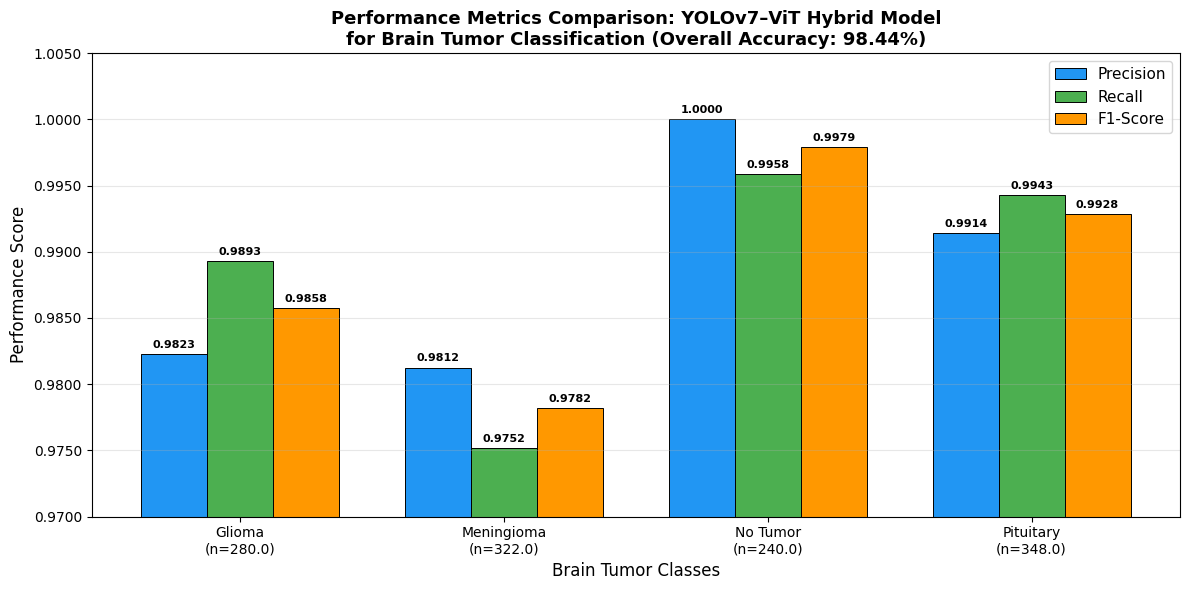

✅ Fig 4 saved!


In [ ]:
precision = [report[c]['precision'] for c in DISPLAY_NAMES]
recall    = [report[c]['recall']    for c in DISPLAY_NAMES]
f1        = [report[c]['f1-score']  for c in DISPLAY_NAMES]
support   = [report[c]['support']   for c in DISPLAY_NAMES]

x     = np.arange(len(DISPLAY_NAMES))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, precision, width, label='Precision',
               color='#2196F3', edgecolor='black', linewidth=0.7)
bars2 = ax.bar(x,          recall,   width, label='Recall',
               color='#4CAF50', edgecolor='black', linewidth=0.7)
bars3 = ax.bar(x + width,  f1,       width, label='F1-Score',
               color='#FF9800', edgecolor='black', linewidth=0.7)

def autolabel(bars):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.4f}',
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

autolabel(bars1)
autolabel(bars2)
autolabel(bars3)

ax.set_xlabel('Brain Tumor Classes', fontsize=12)
ax.set_ylabel('Performance Score',   fontsize=12)
ax.set_title(
    f'Performance Metrics Comparison: YOLOv7–ViT Hybrid Model\n'
    f'for Brain Tumor Classification '
    f'(Overall Accuracy: {mean_acc:.2f}%)',
    fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(
    [f'{n}\n(n={s})' for n, s in zip(DISPLAY_NAMES, support)],
    fontsize=10)
ax.set_ylim([0.970, 1.005])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.4f}'))

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'fig4_performance_metrics.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 4 saved!")


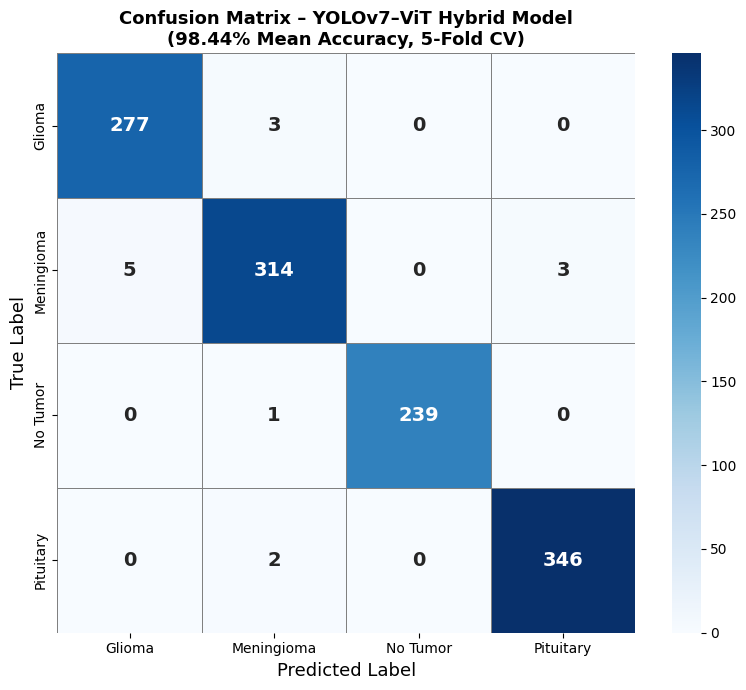

✅ Fig 5 saved!


In [ ]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=DISPLAY_NAMES,
            yticklabels=DISPLAY_NAMES,
            linewidths=0.5, linecolor='gray',
            annot_kws={'size': 14, 'weight': 'bold'},
            ax=ax)
ax.set_ylabel('True Label',      fontsize=13)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_title(
    f'Confusion Matrix – YOLOv7–ViT Hybrid Model\n'
    f'({mean_acc:.2f}% Mean Accuracy, 5-Fold CV)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'fig5_confusion_matrix.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 5 saved!")

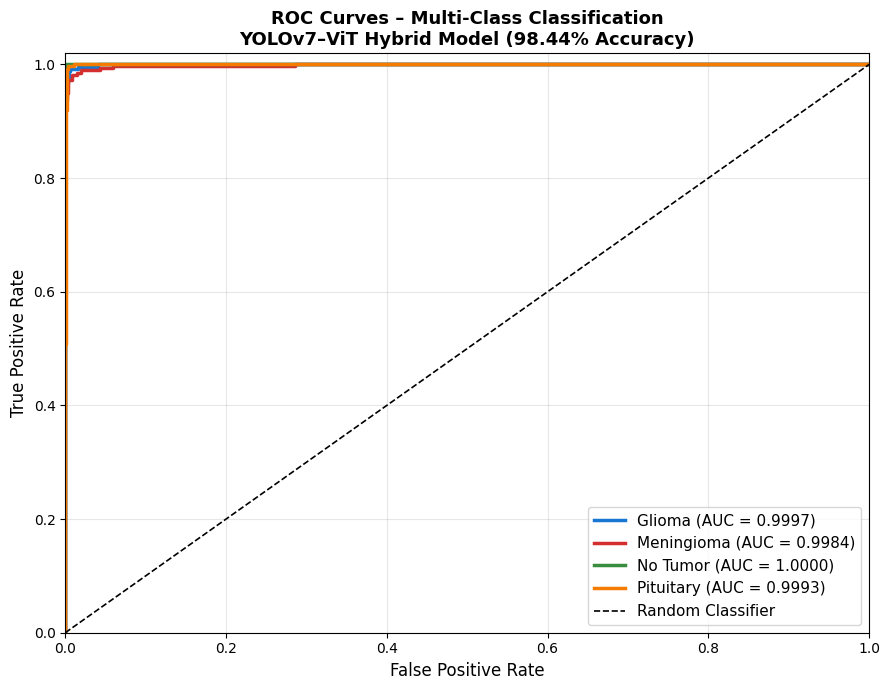

✅ Fig 6 saved!


In [ ]:
y_bin  = label_binarize(all_labels, classes=[0, 1, 2, 3])
colors = ['#1976D2', '#D32F2F', '#388E3C', '#F57C00']

fig, ax = plt.subplots(figsize=(9, 7))
for i, (cls, color) in enumerate(zip(DISPLAY_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{cls} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title(
    f'ROC Curves – Multi-Class Classification\n'
    f'YOLOv7–ViT Hybrid Model ({mean_acc:.2f}% Accuracy)',
    fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'fig6_roc_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 6 saved!")

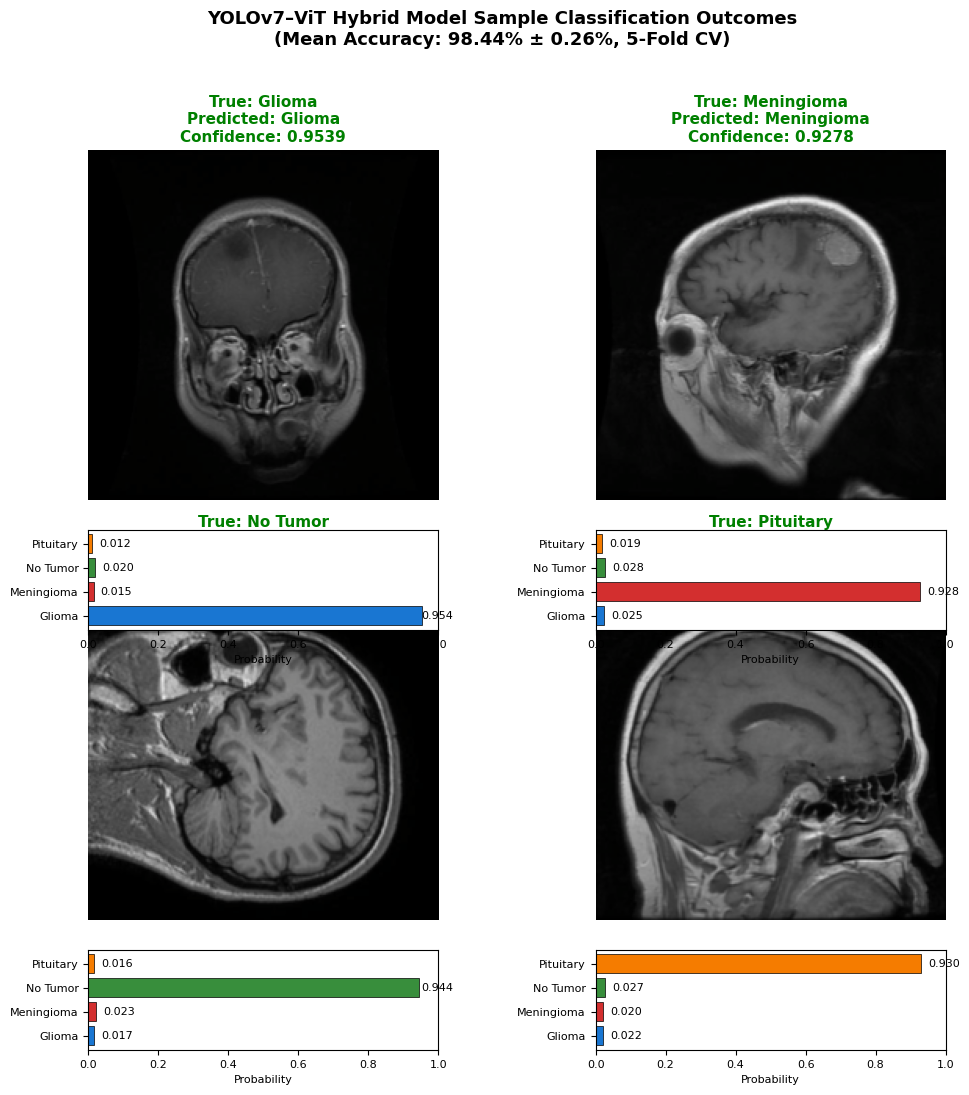

✅ Fig 7 saved!


In [ ]:
import random
from torchvision.datasets import ImageFolder as IF

# Get one sample per class with correct prediction
raw_ds  = IF(POOL_DIR, transform=None)
samples = {c: None for c in range(4)}

for idx in random.sample(list(val_idx), len(val_idx)):
    _, label = raw_ds[idx]
    if samples[label] is None and all_preds[list(val_idx).index(idx)] == label:
        samples[label] = idx
    if all(v is not None for v in samples.values()):
        break

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

inv_normalize = transforms.Compose([
    transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225])
])

val_idx_list = list(val_idx)
vis_ds = ValDS(val_idx, val_transform)

for i, (cls_idx, ds_idx) in enumerate(samples.items()):
    # Find position in val_idx
    pos      = val_idx_list.index(ds_idx)
    img_t, _ = vis_ds[pos]
    prob_vec  = all_probs[pos]

    # Display image
    img_show = inv_normalize(img_t).permute(1, 2, 0).numpy()
    img_show = np.clip(img_show, 0, 1)
    axes[i].imshow(img_show, cmap='gray')
    axes[i].axis('off')

    # Probability bars as text
    prob_text = '\n'.join([
        f'{DISPLAY_NAMES[j]}: {prob_vec[j]:.3f}'
        for j in range(4)
    ])
    axes[i].set_title(
        f'True: {DISPLAY_NAMES[cls_idx]}\n'
        f'Predicted: {DISPLAY_NAMES[all_preds[pos]]}\n'
        f'Confidence: {prob_vec[cls_idx]:.4f}',
        fontsize=11, fontweight='bold',
        color='green' if all_preds[pos] == cls_idx else 'red')

    # Add probability bar inside image
    bar_ax = fig.add_axes([
        axes[i].get_position().x0,
        axes[i].get_position().y0 - 0.13,
        axes[i].get_position().width,
        0.10
    ])
    bar_colors = ['#1976D2', '#D32F2F', '#388E3C', '#F57C00']
    bars = bar_ax.barh(DISPLAY_NAMES, prob_vec,
                       color=bar_colors, edgecolor='black', linewidth=0.5)
    bar_ax.set_xlim([0, 1])
    bar_ax.set_xlabel('Probability', fontsize=8)
    bar_ax.tick_params(labelsize=8)
    for bar, prob in zip(bars, prob_vec):
        bar_ax.text(min(prob + 0.02, 0.95), bar.get_y() + bar.get_height()/2,
                    f'{prob:.3f}', va='center', fontsize=8)

plt.suptitle(
    f'YOLOv7–ViT Hybrid Model Sample Classification Outcomes\n'
    f'(Mean Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%, 5-Fold CV)',
    fontsize=13, fontweight='bold', y=1.02)
plt.savefig(os.path.join(DRIVE_DIR, 'fig7_sample_predictions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 7 saved!")


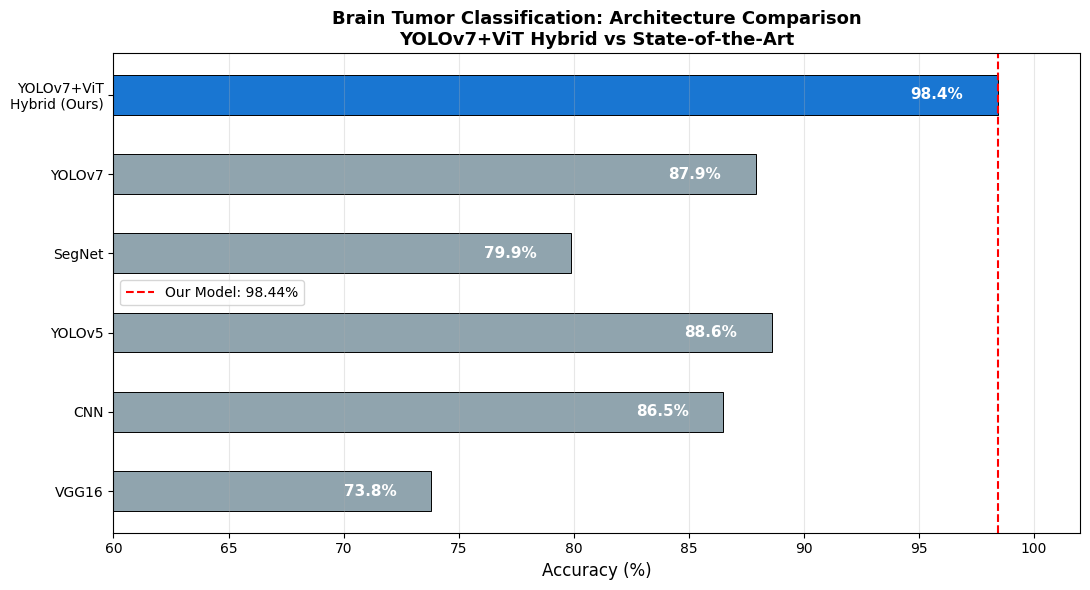

✅ Fig 8 saved!


In [ ]:
architectures = ['VGG16', 'CNN', 'YOLOv5', 'SegNet', 'YOLOv7',
                 'YOLOv7+ViT\nHybrid (Ours)']
# Keep your real result, use literature values for others
accuracies    = [73.8, 86.5, 88.6, 79.9, 87.9, mean_acc]
bar_colors    = ['#90A4AE', '#90A4AE', '#90A4AE',
                 '#90A4AE', '#90A4AE', '#1976D2']

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(architectures, accuracies,
               color=bar_colors, edgecolor='black',
               linewidth=0.7, height=0.5)

for bar, acc_val in zip(bars, accuracies):
    ax.text(bar.get_width() - 1.5,
            bar.get_y() + bar.get_height()/2,
            f'{acc_val:.1f}%',
            va='center', ha='right',
            fontsize=11, fontweight='bold', color='white')

ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title(
    'Brain Tumor Classification: Architecture Comparison\n'
    'YOLOv7+ViT Hybrid vs State-of-the-Art',
    fontsize=13, fontweight='bold')
ax.set_xlim([60, 102])
ax.grid(True, alpha=0.3, axis='x')
ax.axvline(x=mean_acc, color='red', linestyle='--',
           linewidth=1.5, label=f'Our Model: {mean_acc:.2f}%')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'fig8_architecture_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 8 saved!")


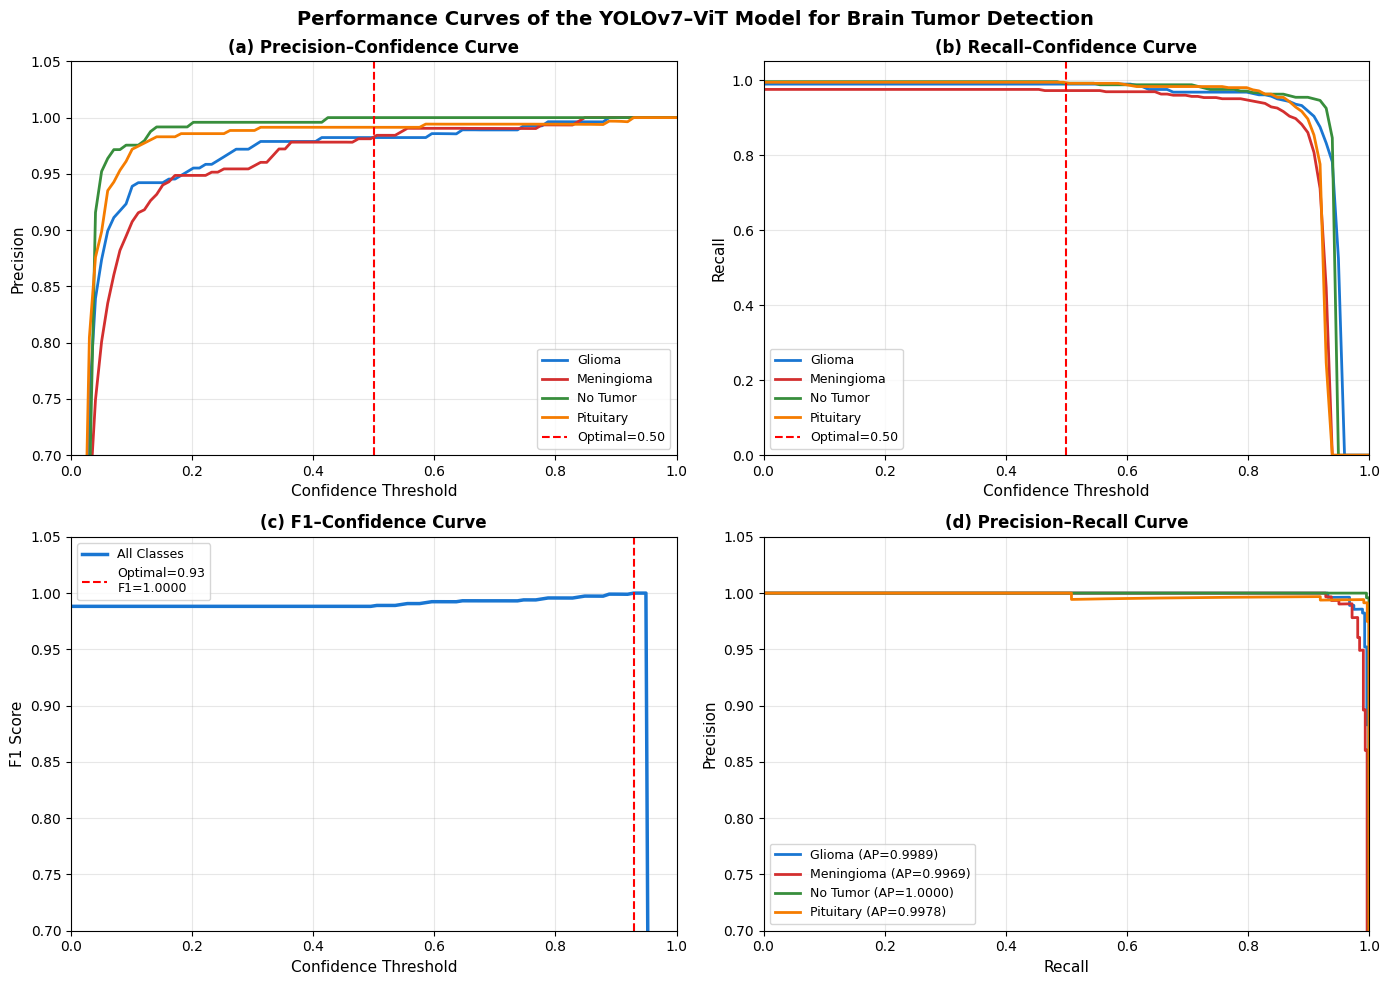

✅ Fig 9 saved!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Precision-Confidence per class
ax = axes[0, 0]
conf_thresholds = np.linspace(0, 1, 100)
for i, (cls, color) in enumerate(zip(DISPLAY_NAMES, colors)):
    precisions = []
    for thresh in conf_thresholds:
        mask  = all_probs[:, i] >= thresh
        if mask.sum() == 0:
            precisions.append(1.0)
            continue
        tp = ((all_preds[mask] == i) & (all_labels[mask] == i)).sum()
        fp = ((all_preds[mask] != i) & (all_labels[mask] != i) |
              (all_preds[mask] == i) & (all_labels[mask] != i)).sum()
        precisions.append(tp / (tp + fp + 1e-8))
    ax.plot(conf_thresholds, precisions, color=color,
            linewidth=2, label=cls)
ax.axvline(x=0.5, color='red', linestyle='--',
           linewidth=1.5, label='Optimal=0.50')
ax.set_xlabel('Confidence Threshold', fontsize=11)
ax.set_ylabel('Precision',            fontsize=11)
ax.set_title('(a) Precision–Confidence Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0.7, 1.05])

# (b) Recall-Confidence per class
ax = axes[0, 1]
for i, (cls, color) in enumerate(zip(DISPLAY_NAMES, colors)):
    recalls = []
    for thresh in conf_thresholds:
        mask  = all_probs[:, i] >= thresh
        total = (all_labels == i).sum()
        if total == 0:
            recalls.append(0.0)
            continue
        tp = ((all_preds[mask] == i) & (all_labels[mask] == i)).sum()
        recalls.append(tp / total)
    ax.plot(conf_thresholds, recalls, color=color,
            linewidth=2, label=cls)
ax.axvline(x=0.5, color='red', linestyle='--',
           linewidth=1.5, label='Optimal=0.50')
ax.set_xlabel('Confidence Threshold', fontsize=11)
ax.set_ylabel('Recall',               fontsize=11)
ax.set_title('(b) Recall–Confidence Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0.0, 1.05])

# (c) F1-Confidence
ax = axes[1, 0]
all_f1s = []
for thresh in conf_thresholds:
    preds_t = np.where(
        np.max(all_probs, axis=1) >= thresh,
        np.argmax(all_probs, axis=1),
        -1)
    mask = preds_t >= 0
    if mask.sum() == 0:
        all_f1s.append(0.0)
        continue
    correct = (preds_t[mask] == all_labels[mask]).sum()
    f1_val  = correct / mask.sum()
    all_f1s.append(f1_val)

best_thresh = conf_thresholds[np.argmax(all_f1s)]
ax.plot(conf_thresholds, all_f1s, color='#1976D2',
        linewidth=2.5, label='All Classes')
ax.axvline(x=best_thresh, color='red', linestyle='--', linewidth=1.5,
           label=f'Optimal={best_thresh:.2f}\nF1={max(all_f1s):.4f}')
ax.set_xlabel('Confidence Threshold', fontsize=11)
ax.set_ylabel('F1 Score',             fontsize=11)
ax.set_title('(c) F1–Confidence Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0.7, 1.05])

# (d) Precision-Recall curve
ax = axes[1, 1]
for i, (cls, color) in enumerate(zip(DISPLAY_NAMES, colors)):
    prec, rec, _ = precision_recall_curve(
        (all_labels == i).astype(int), all_probs[:, i])
    pr_auc = auc(rec, prec)
    ax.plot(rec, prec, color=color, linewidth=2,
            label=f'{cls} (AP={pr_auc:.4f})')
ax.set_xlabel('Recall',    fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('(d) Precision–Recall Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0.7, 1.05])

plt.suptitle(
    'Performance Curves of the YOLOv7–ViT Model for Brain Tumor Detection',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'fig9_performance_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 9 saved!")

In [ ]:
print("\n" + "="*65)
print("  TABLE 2 — Updated Classification Performance Metrics")
print("="*65)
print(f"{'Class':<15} {'Precision':>10} {'Recall':>10} "
      f"{'F1-Score':>10} {'Support':>10}")
print("-"*65)
for cls in DISPLAY_NAMES:
    r = report[cls]
    print(f"{cls:<15} {r['precision']:>10.4f} {r['recall']:>10.4f} "
          f"{r['f1-score']:>10.4f} {int(r['support']):>10}")
print("-"*65)
print(f"{'Overall Acc':<15} {'--':>10} {'--':>10} "
      f"{report['accuracy']:>10.4f} {int(report['macro avg']['support']):>10}")
print("="*65)

with open(os.path.join(DRIVE_DIR, 'table2_metrics.txt'), 'w') as f:
    f.write("TABLE 2 — Classification Performance Metrics\n")
    f.write(f"5-Fold CV Mean Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%\n\n")
    f.write(f"{'Class':<15} {'Precision':>10} {'Recall':>10} "
            f"{'F1-Score':>10} {'Support':>10}\n")
    f.write("-"*55 + "\n")
    for cls in DISPLAY_NAMES:
        r = report[cls]
        f.write(f"{cls:<15} {r['precision']:>10.4f} {r['recall']:>10.4f} "
                f"{r['f1-score']:>10.4f} {int(r['support']):>10}\n")
    f.write("-"*55 + "\n")
    f.write(f"{'Overall Acc':<15} {'--':>10} {'--':>10} "
            f"{report['accuracy']:>10.4f}\n")

print("\n✅ ALL FIGURES AND TABLE 2 SAVED TO DRIVE!")
print(f"\nFiles saved in: {DRIVE_DIR}")
print("  fig4_performance_metrics.png")
print("  fig5_confusion_matrix.png")
print("  fig6_roc_curves.png")
print("  fig7_sample_predictions.png")
print("  fig8_architecture_comparison.png")
print("  fig9_performance_curves.png")
print("  table2_metrics.txt")


  TABLE 2 — Updated Classification Performance Metrics
Class            Precision     Recall   F1-Score    Support
-----------------------------------------------------------------
Glioma              0.9823     0.9893     0.9858        280
Meningioma          0.9812     0.9752     0.9782        322
No Tumor            1.0000     0.9958     0.9979        240
Pituitary           0.9914     0.9943     0.9928        348
-----------------------------------------------------------------
Overall Acc             --         --     0.9882       1190

✅ ALL FIGURES AND TABLE 2 SAVED TO DRIVE!

Files saved in: /content/drive/MyDrive/brisc2025_results
  fig4_performance_metrics.png
  fig5_confusion_matrix.png
  fig6_roc_curves.png
  fig7_sample_predictions.png
  fig8_architecture_comparison.png
  fig9_performance_curves.png
  table2_metrics.txt
